In [72]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datatree import DataTree, open_datatree

from isca_tools.utils.fourier import coef_conversion
from isca_tools.utils.xarray import convert_ds_dtypes
from pathlib import Path
import os
import warnings
from glob import glob
from tqdm.notebook import tqdm

from isca_tools.utils.moist_physics import sphum_sat
import jobs.thesis_season.thesis_figs.utils as utils
from jobs.era5.surface_flux.av_annual_cycle.hysteresis_check_get_data import get_rh

In [73]:
data_dir = f'/Users/joshduffield/Documents/StAndrews/Isca/jobs/era5/surface_flux/av_annual_cycle/output_20years/'
ds = xr.open_mfdataset(f'{data_dir}/*.nc')

load_indiv_flux = False
files_fourier = sorted(glob(os.path.join(data_dir, "fourier_coef", "*.nc")))
if not load_indiv_flux:
    files_fourier = [file for file in files_fourier if 'ms' not in file]
var = {}
for i, file in tqdm(enumerate(files_fourier), total=len(files_fourier)):
    key = Path(file).stem
    if key == 'net_up_flux':
        var[key] = {'simulated': (-ds.mslhf - ds.msshf - ds.msnlwrf).load()}
    else:
        var[key] = {'simulated': ds[key].load()}

  0%|          | 0/2 [00:00<?, ?it/s]

In [77]:
with tqdm(total=2) as pbar:
    var['rh_atm'] = {'simulated': get_rh(ds.d2m, ds.t2m, ds.sp).load()}
    pbar.update(1)
    var['w_atm'] = {'simulated': np.sqrt(ds['u10'] ** 2 + ds['v10'] ** 2).load()}
    pbar.update(1)

In [56]:
# Load in fourier coefficients
fourier_coef = {}
for key in ['amp', 'phase']:
    fourier_coef[key] = xr.merge([
        xr.open_dataset(f)[[key]].rename({key: Path(f).stem})
        for f in files_fourier
    ])
    fourier_coef[key] = fourier_coef[key].load()

In [57]:
# Compute annual harmonic
for i, key in tqdm(enumerate(var), total=len(var)):
    var[key]['direct'] = utils.fourier_series_xr(np.arange(ds.time.size), fourier_coef['amp'][key],
                                                    fourier_coef['phase'][key], pad_coefs_phase=True).astype('float32')

  0%|          | 0/2 [00:00<?, ?it/s]

In [58]:
if load_indiv_flux:
    # Sanity check that sum of direct harmonics equals direct harmonic of sum
    np.abs((-var['mslhf']['direct'] - var['msshf']['direct'] - var['msnlwrf']['direct']) - var['net_up_flux']['direct']).max()

In [59]:
fit_params = xr.open_mfdataset(f'{data_dir}/empirical_fitting/*.nc').load()

In [60]:
# Sanity check that sum of fit parameters equal fit parameters of sum
(np.abs((-fit_params['mslhf'] - fit_params['msshf'] - fit_params['msnlwrf']) -
        fit_params['net_up_flux']).sel(fit_method='linear_phase')).quantile(0.95, dim=['longitude', 'latitude'])

<xarray.DataArray (deg: 6)> Size: 48B
array([4.33921814e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.90734863e-06, 4.88281250e-04])
Coordinates:
  * deg       (deg) <U5 120B 'phase' 'cos' 'sin' '2' '1' '0'
    quantile  float64 8B 0.95

In [65]:
var.keys()

dict_keys(['net_up_flux', 'skt'])

In [64]:
fit_params = xr.open_mfdataset(f'{data_dir}/empirical_fitting/*.nc').load()
var_to_fit = ['net_up_flux', 'rh_atm', 'w_atm']
with tqdm(total=2*len(var_to_fit)) as pbar:
    for key in var_to_fit:
        for key2 in ['linear', 'linear_phase']:
            # Use actual skt for variable e.g. wind and rh but annual harmonic for the fluxes
            var[key][key2] = utils.polyval_phase_xr(fit_params[key].sel(fit_method=key2),
                                                    var['skt']['simulated' if 'atm' in key2 else 'direct']).astype('float32')
            pbar.update(1)

  0%|          | 0/6 [00:00<?, ?it/s]

KeyError: 'rh_atm'

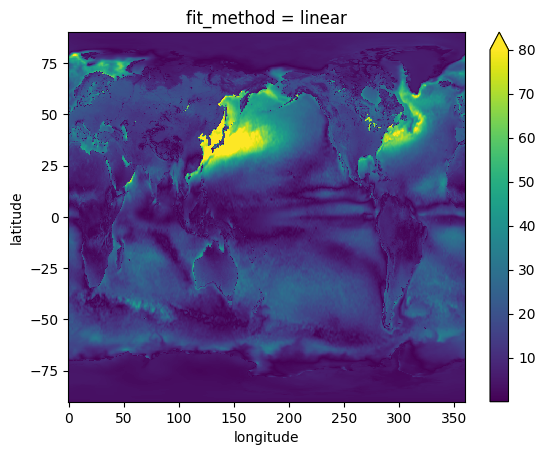

In [23]:
key = 'net_up_flux'
(np.abs(var[key]['direct'] - var[key]['linear']).mean(dim='time')).plot(vmax=40)

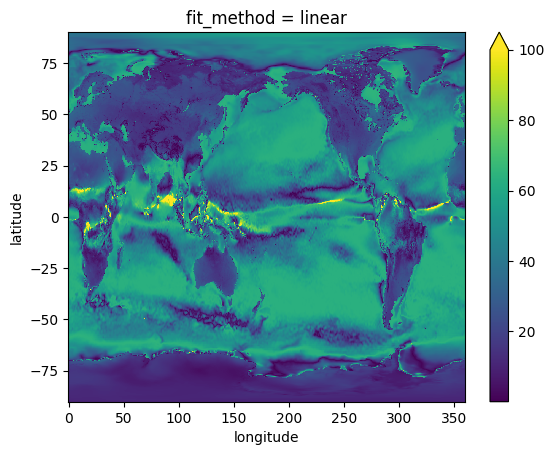

In [44]:
(2*100*(np.abs(var[key]['direct'] - var[key]['linear']).mean(dim='time')
        )/(var[key]['direct'].max(dim='time') - var[key]['direct'].min(dim='time'))).plot(vmax=100)

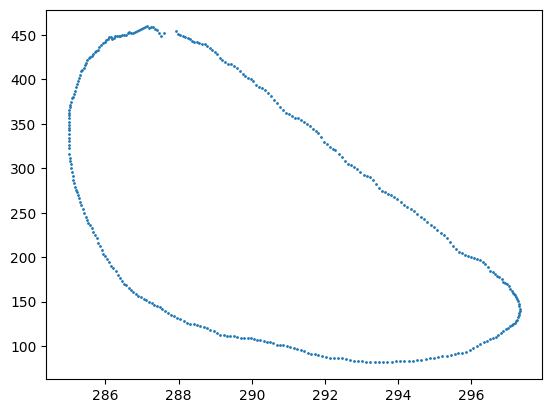

In [98]:
plt.scatter(var['skt']['simulated'].sel(longitude=lon_use, latitude=lat_use, method='nearest'), var[key]['simulated'].sel(longitude=lon_use, latitude=lat_use, method='nearest'), s=1)

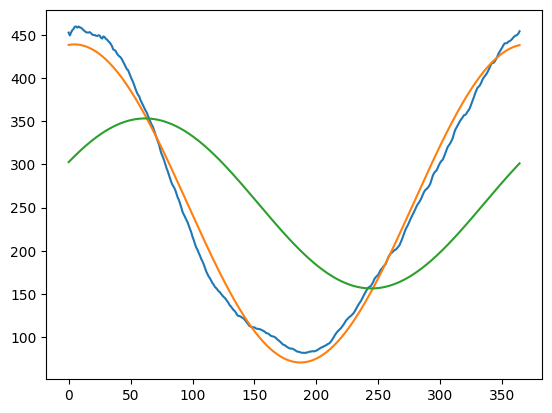

In [97]:
lon_use = 150
lat_use = 38
for key2 in ['simulated', 'direct', 'linear']:
    plt.plot(np.arange(ds.time.size), var[key][key2].sel(longitude=lon_use, latitude=lat_use, method='nearest'))

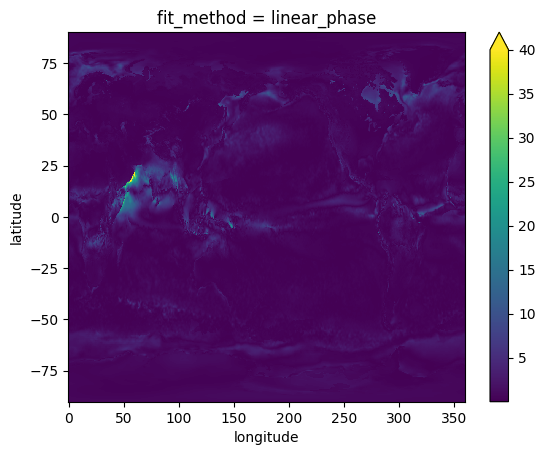

In [12]:
(np.abs(var[key]['direct'] - var[key]['linear_phase']).mean(dim='time')).plot(vmax=40)

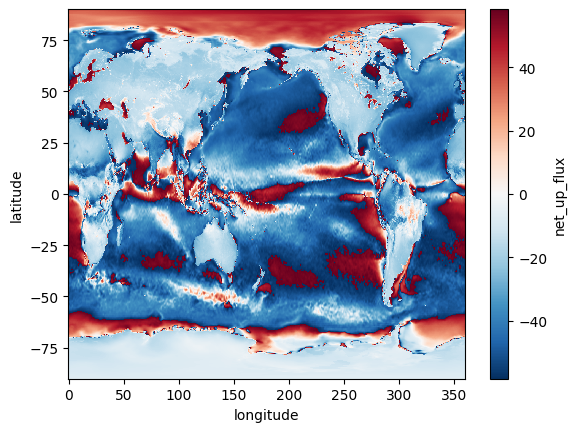

In [35]:
param_use = coef_conversion(cos_coef=fit_params[key].sel(fit_method='linear', deg='1'),
                sin_coef=fit_params[key].sel(fit_method='linear_phase', deg='phase'), take_cos_sign=True)[1]
(np.arctan(param_use) / (2 * np.pi / ds.time.size)).plot()

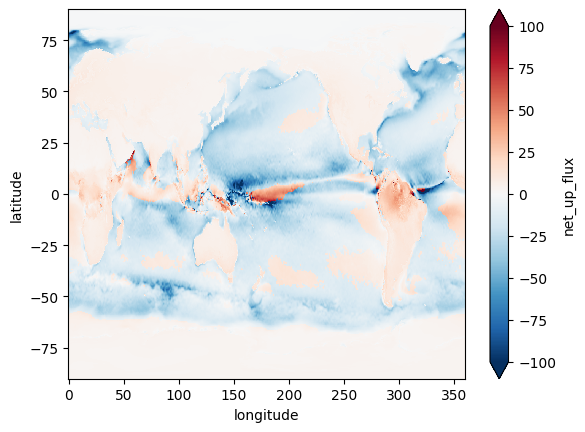

In [28]:
coef_conversion(cos_coef=fit_params[key].sel(fit_method='linear', deg='1'),
                sin_coef=fit_params[key].sel(fit_method='linear_phase', deg='phase'), take_cos_sign=True)[0].plot(vmax=100)

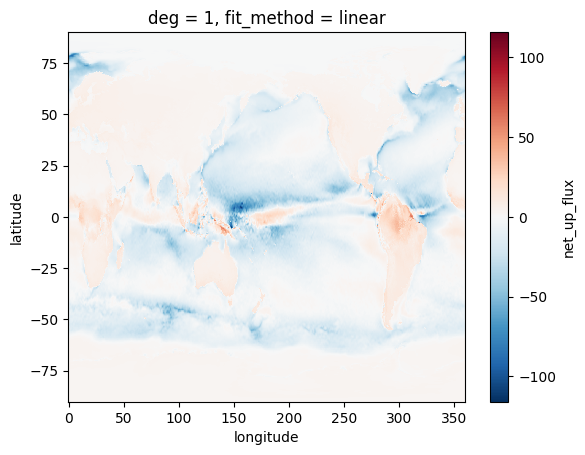

In [22]:
fit_params[key].sel(fit_method='linear', deg='1').plot()

In [ ]:
flux_pa

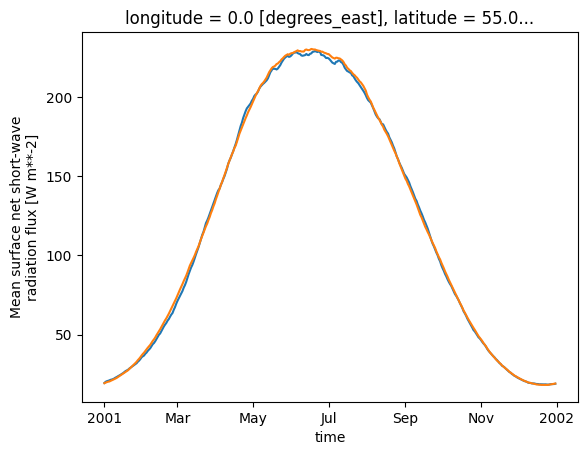

In [75]:
lat_ind = 55
lon_ind = 0
ds5.sel(latitude=lat_ind, longitude=lon_ind, method='nearest').plot()
ds20.sel(latitude=lat_ind, longitude=lon_ind, method='nearest').plot()

In [13]:
out_path = os.path.join(data_dir, f"ds_processed.nc")
tree_load = open_datatree(out_path)

In [25]:
var = 'mslhf'
fourier_coefs = xr.load_dataset(f"{data_dir}/fourier_coef/{var}.nc")

In [28]:
fourier_coefs.attrs['n_time'] = 365

In [34]:
ds = xr.open_dataset(f"{data_dir}/{var}.nc")

In [38]:
ds_fourier = utils.fourier_series_xr(np.arange(fourier_coefs.n_time), fourier_coefs['amp'], fourier_coefs['phase'],
                                     pad_coefs_phase=True)

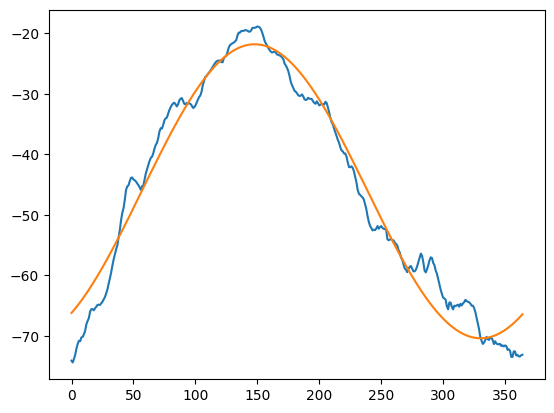

In [44]:
plt.plot(np.arange(fourier_coefs.n_time), ds.isel(latitude=140, longitude=0)[var])
plt.plot(np.arange(fourier_coefs.n_time), ds_fourier.isel(latitude=140, longitude=0))

In [26]:
fourier_coefs

<xarray.Dataset> Size: 17MB
Dimensions:    (longitude: 1440, latitude: 721, harmonic: 2)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level      int32 4B 137
Dimensions without coordinates: harmonic
Data variables:
    amp        (latitude, longitude, harmonic) float32 8MB -9.868 ... -0.05027
    phase      (latitude, longitude, harmonic) float32 8MB 0.0 ... -0.8582

In [17]:
skt_fourier = tree_load['ds_out'].temp_surf.sel(fit_method='direct').load().to_dataset(name='skt')

In [21]:
complevel = 4
skt_fourier = convert_ds_dtypes(skt_fourier.reset_coords(drop=True))
encoding = {var: {'zlib': True, 'complevel': complevel} for var in skt_fourier.data_vars}
out_path_use = os.path.join(data_dir, 'processed', f"skt_annual_harmonic.nc")
skt_fourier.to_netcdf(out_path_use, encoding=encoding)

In [24]:
tree_load['ds_out']

DataTree('ds_out', parent="None")
    Dimensions:      (longitude: 1440, latitude: 721, time: 365, fit_method: 4)
    Coordinates:
      * longitude    (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
      * latitude     (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
      * time         (time) datetime64[ns] 3kB 2001-01-01 2001-01-02 ... 2001-12-31
      * fit_method   (fit_method) <U12 192B 'simulated' 'direct' ... 'linear_phase'
        level        int32 4B 137
    Data variables:
        net_up_flux  (fit_method, time, latitude, longitude) float64 12GB ...
        temp_surf    (fit_method, time, latitude, longitude) float32 6GB ...

In [19]:
net_up_flux = tree_load['ds_out']['net_up_flux'].to_dataset(name='net_up_flux')
net_up_flux = net_up_flux.sel(fit_method=net_up_flux.fit_method == "direct")  # just save direct fourier fit
net_up_flux = convert_ds_dtypes(net_up_flux).squeeze().reset_coords(drop=True)

In [24]:
encoding = {var: {'zlib': True, 'complevel': complevel} for var in net_up_flux.data_vars}
out_path_use = os.path.join(data_dir, 'processed', f"net_up_flux_annual_harmonic.nc")
net_up_flux.to_netcdf(out_path_use, encoding=encoding)

In [47]:
fit_params = convert_ds_dtypes(tree_load['fit_params'].to_dataset())
encoding = {var: {'zlib': True, 'complevel': complevel} for var in fit_params.data_vars}
out_path_use = os.path.join(data_dir, 'processed', f"fit_params.nc")
fit_params.to_netcdf(out_path_use, encoding=encoding)

In [3]:
ds = xr.open_mfdataset(f'{data_dir}/*.nc')
# ds = ds.sel(latitude=slice(60, 50), longitude=slice(330, 360))

In [4]:
%%time
net_up_flux = {'simulated': (-ds.mslhf - ds.msshf - ds.msnlwrf).load()}
skt = {'simulated': ds.skt.load()}
# w_atm = np.sqrt(ds.u ** 2 + ds.v ** 2)
# w_atm = np.sqrt(ds.u10 ** 2 + ds.v10 ** 2).load()
# rh_atm = ds.q / sphum_sat(ds.t, ds.sp)

CPU times: user 15 s, sys: 4.37 s, total: 19.4 s
Wall time: 19.1 s


In [5]:
%%time
net_up_flux['direct'] = xr.open_dataset(f'{data_dir}/processed/net_up_flux.nc')['net_up_flux'].sel(
    fit_method='direct').load()
skt['direct'] = xr.open_dataset(f'{data_dir}/processed/skt_annual_harmonic.nc')['skt'].load()

CPU times: user 7.48 s, sys: 1.78 s, total: 9.25 s
Wall time: 9.43 s


In [8]:
fit_params = xr.load_dataset(f'{data_dir}/processed/fit_params.nc')

In [11]:
for key in ['linear', 'linear_phase']:
    net_up_flux[key] = utils.polyval_phase_xr(fit_params['net_up_flux'].sel(fit_method=key), skt['direct'])

In [9]:
fit_params

<xarray.Dataset> Size: 100MB
Dimensions:      (longitude: 1440, latitude: 721, deg: 6, fit_method: 2)
Coordinates:
  * longitude    (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude     (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * deg          (deg) <U5 120B 'phase' 'cos' 'sin' '2' '1' '0'
    level        int32 4B 137
  * fit_method   (fit_method) <U12 96B 'linear' 'linear_phase'
Data variables:
    net_up_flux  (fit_method, latitude, longitude, deg) float32 50MB 0.0 ... ...
    w_atm        (fit_method, latitude, longitude, deg) float32 50MB 0.0 ... ...

In [5]:
%%time
net_up_flux['direct'] = \
    utils.get_fourier_fit_xr(np.arange(ds.time.size), net_up_flux['simulated'], n_harmonics=1, pad_coefs_phase=True)[0]
temp_surf['direct'] = \
    utils.get_fourier_fit_xr(np.arange(ds.time.size), temp_surf['simulated'], n_harmonics=1, pad_coefs_phase=True)[0]

CPU times: user 4.04 s, sys: 16.1 ms, total: 4.05 s
Wall time: 4.06 s


In [6]:
%%time
net_up_flux_params = {}
w_atm_params = {}
for key in ['linear', 'linear_phase']:
    # Compute params with simulated flux
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", np.RankWarning)
        net_up_flux_params[key] = utils.polyfit_phase_xr(temp_surf['simulated'], net_up_flux['simulated'], deg=1,
                                                         include_phase='phase' in key, include_fourier=False,
                                                         deg_phase_calc=10)
        w_atm_params[key] = utils.polyfit_phase_xr(temp_surf['simulated'], w_atm, deg=1,
                                                   include_phase='phase' in key, include_fourier=False,
                                                   deg_phase_calc=10)
    # Apply params with single harmonic temp
    net_up_flux[key] = utils.polyval_phase_xr(net_up_flux_params[key], temp_surf['direct'])

CPU times: user 2.81 s, sys: 17.1 ms, total: 2.83 s
Wall time: 2.83 s


In [7]:
ds_out = xr.concat(net_up_flux.values(), dim=pd.Index(net_up_flux.keys(), name="fit_method")).to_dataset(
    name="net_up_flux")
ds_out['temp_surf'] = xr.concat(temp_surf.values(), dim=pd.Index(temp_surf.keys(), name="fit_method"))
fit_params = xr.concat(net_up_flux_params.values(),
                       dim=pd.Index(net_up_flux_params.keys(), name="fit_method")).to_dataset(name="net_up_flux")
fit_params['w_atm'] = xr.concat(w_atm_params.values(),
                                dim=pd.Index(net_up_flux_params.keys(), name="fit_method"))

In [8]:
tree_out = DataTree.from_dict({'ds_out': ds_out, 'fit_params': fit_params})
out_path = os.path.join(data_dir, f"ds_processed.nc")
tree_out.to_netcdf(out_path)

In [10]:
tree_load = open_datatree(out_path)

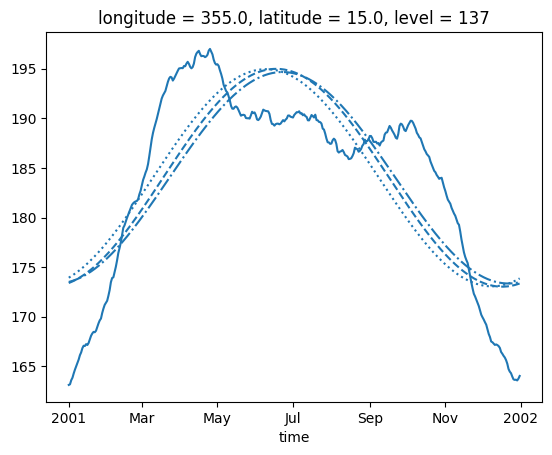

In [78]:
for i, key in enumerate(net_up_flux):
    net_up_flux[key].sel(latitude=15, longitude=355, method='nearest').plot(color='C0',
                                                                            linestyle=['-', '--', '-.', ':'][i])
# temp_surf_fit.sel(latitude=57, longitude=355, method='nearest').plot(color='C0', linestyle=':')
# temp_surf.sel(latitude=57, longitude=335, method='nearest').plot(color='C1')
# temp_surf_fit.sel(latitude=57, longitude=335, method='nearest').plot(color='C1', linestyle=':')

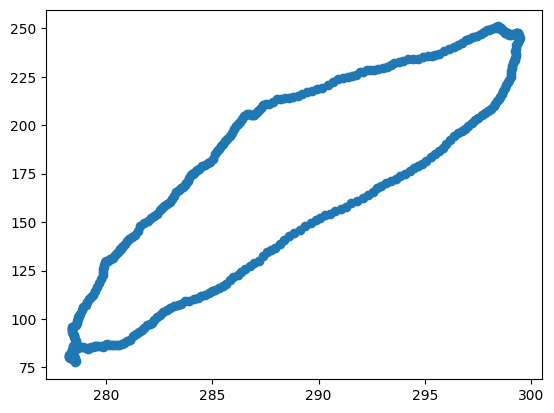

In [82]:
plt.scatter(temp_surf['simulated'].sel(latitude=40, longitude=355, method='nearest'),
            net_up_flux['simulated'].sel(latitude=40, longitude=355, method='nearest'))

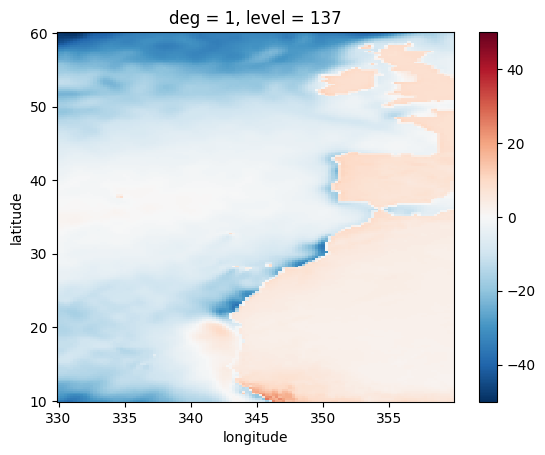

In [85]:
net_up_flux_params['linear'].sel(deg='1').plot()

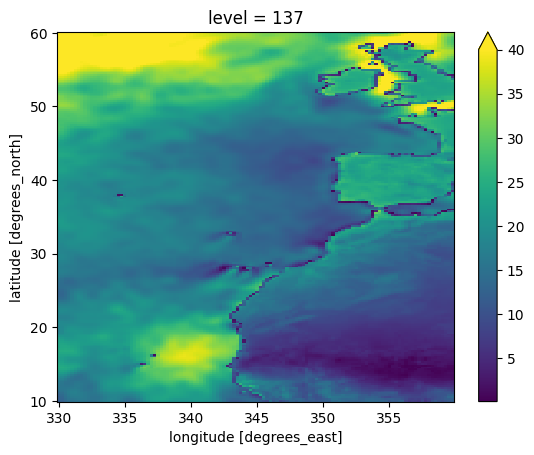

In [76]:
(np.abs(net_up_flux['direct'] - net_up_flux['linear']).mean(dim='time')).plot(vmax=40)

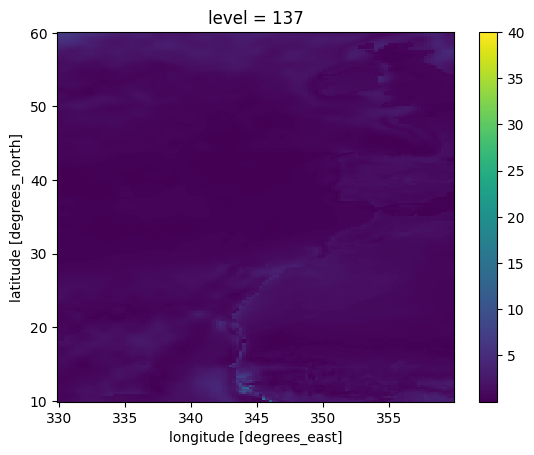

In [87]:
(np.abs(net_up_flux['direct'] - net_up_flux['linear_phase'])).mean(dim='time').plot(vmax=40)

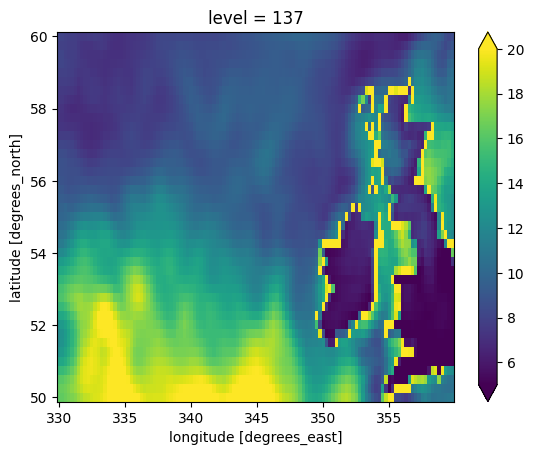

In [60]:
(np.abs(net_up_flux - flux_fit).mean(dim='time') * 200 / (
        net_up_flux.max(dim='time') - net_up_flux.min(dim='time'))).plot(vmax=20, vmin=5)

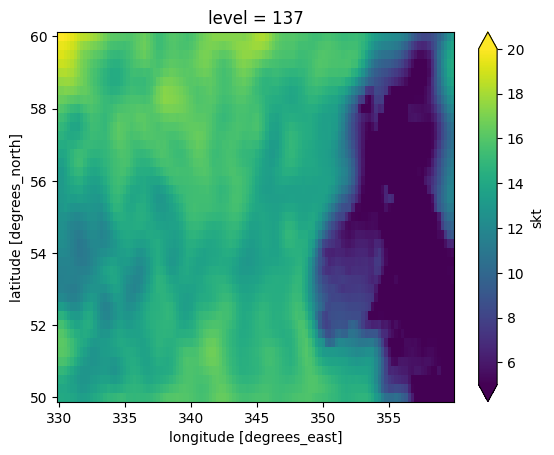

In [59]:
(np.abs(temp_surf - temp_surf_fit).mean(dim='time') * 200 / (
        temp_surf.max(dim='time') - temp_surf.min(dim='time'))).plot(vmax=20, vmin=5)

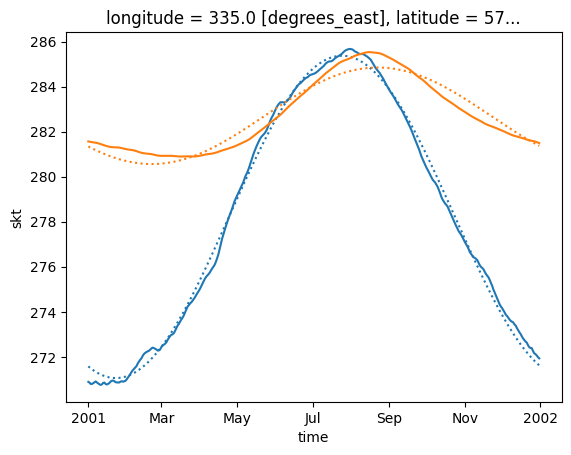

In [65]:
temp_surf.sel(latitude=57, longitude=355, method='nearest').plot(color='C0')
temp_surf_fit.sel(latitude=57, longitude=355, method='nearest').plot(color='C0', linestyle=':')
temp_surf.sel(latitude=57, longitude=335, method='nearest').plot(color='C1')
temp_surf_fit.sel(latitude=57, longitude=335, method='nearest').plot(color='C1', linestyle=':')

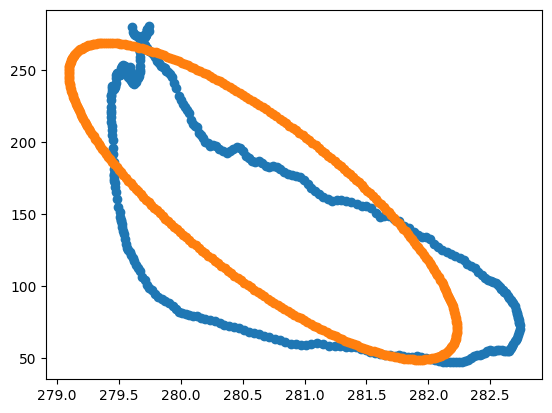

In [25]:
plt.scatter(temp_surf.isel(latitude=0, longitude=0), net_up_flux.isel(latitude=0, longitude=0))
plt.scatter(temp_surf_fit.isel(latitude=0, longitude=0), flux_fit.isel(latitude=0, longitude=0))

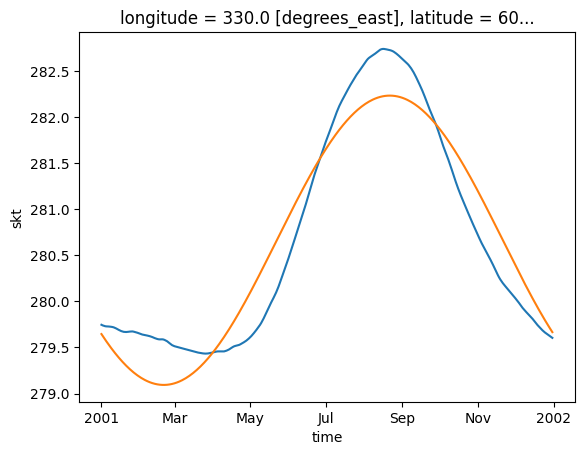

In [26]:
temp_surf.isel(latitude=0, longitude=0).plot()
temp_surf_fit.isel(latitude=0, longitude=0).plot()

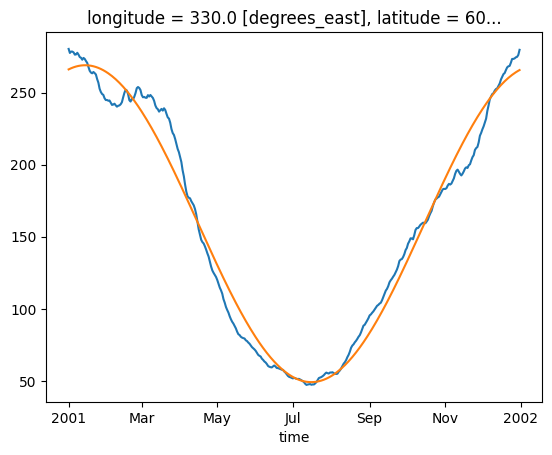

In [22]:
net_up_flux.isel(latitude=0, longitude=0).plot()
flux_fit.isel(latitude=0, longitude=0).plot()

In [145]:
ds_use = ds.sel(latitude=50, longitude=360 - 30, method='nearest').load()
ds_use['w_atm'] = np.sqrt(ds_use.u ** 2 + ds_use.v ** 2)
ds_use['rh_atm'] = ds_use.q / sphum_sat(ds_use.t, ds_use.sp)
ds_use['t_dq'] = ds_use.skt - ds_use.t
ds_use['net_up_flux'] = -ds_use.mslhf - ds_use.msshf - ds_use.msnlwrf

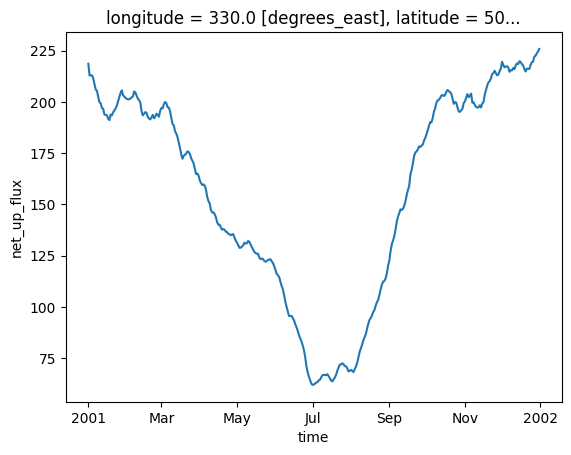

In [146]:
ds_use.net_up_flux.plot()

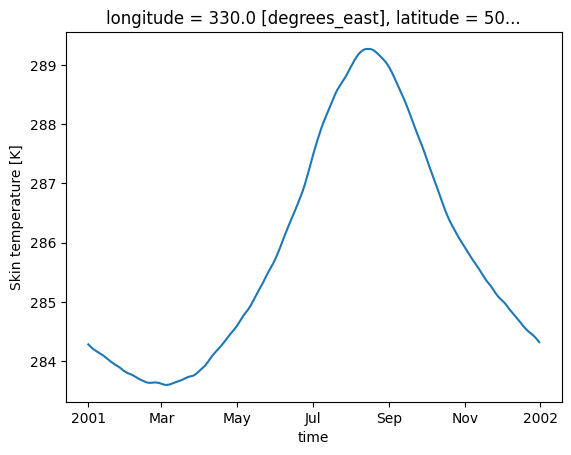

In [147]:
ds_use.skt.plot()
# ds_use.msshf.plot()

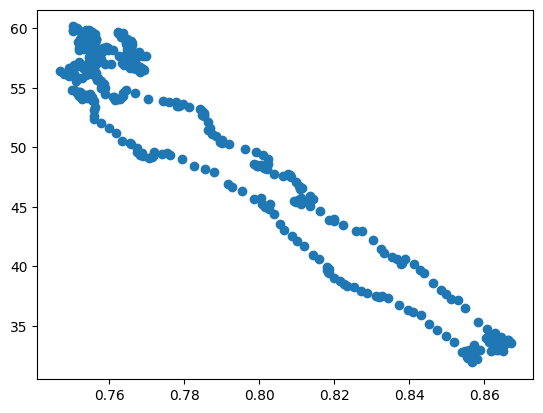

In [148]:
plt.scatter(ds_use.rh_atm, -ds_use.msnlwrf)

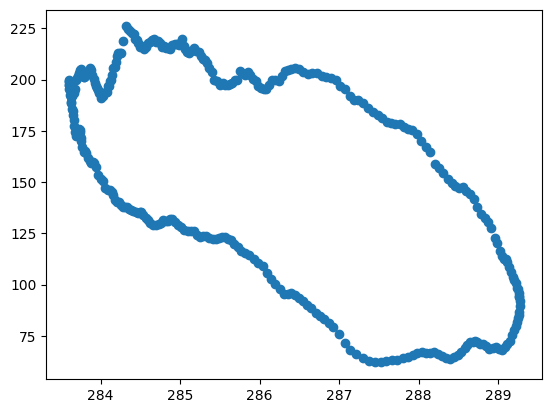

In [149]:
plt.scatter(ds_use.skt, ds_use.net_up_flux)

In [150]:
ds.sel(latitude=50, longitude=360 - 30, method='nearest').plot()
ds.sel(latitude=0, longitude=300, method='nearest').plot()

ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)